<a href="https://colab.research.google.com/github/Alian-123/adaboost-breast-cancer-classification/blob/main/BREAST_CANCER___ADABOOST_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ All libraries imported successfully!
📊 Dataset Shape: (569, 32)

🔢 Class Distribution:
diagnosis
Benign       357
Malignant    212
Name: count, dtype: int64

📋 First 5 Rows:


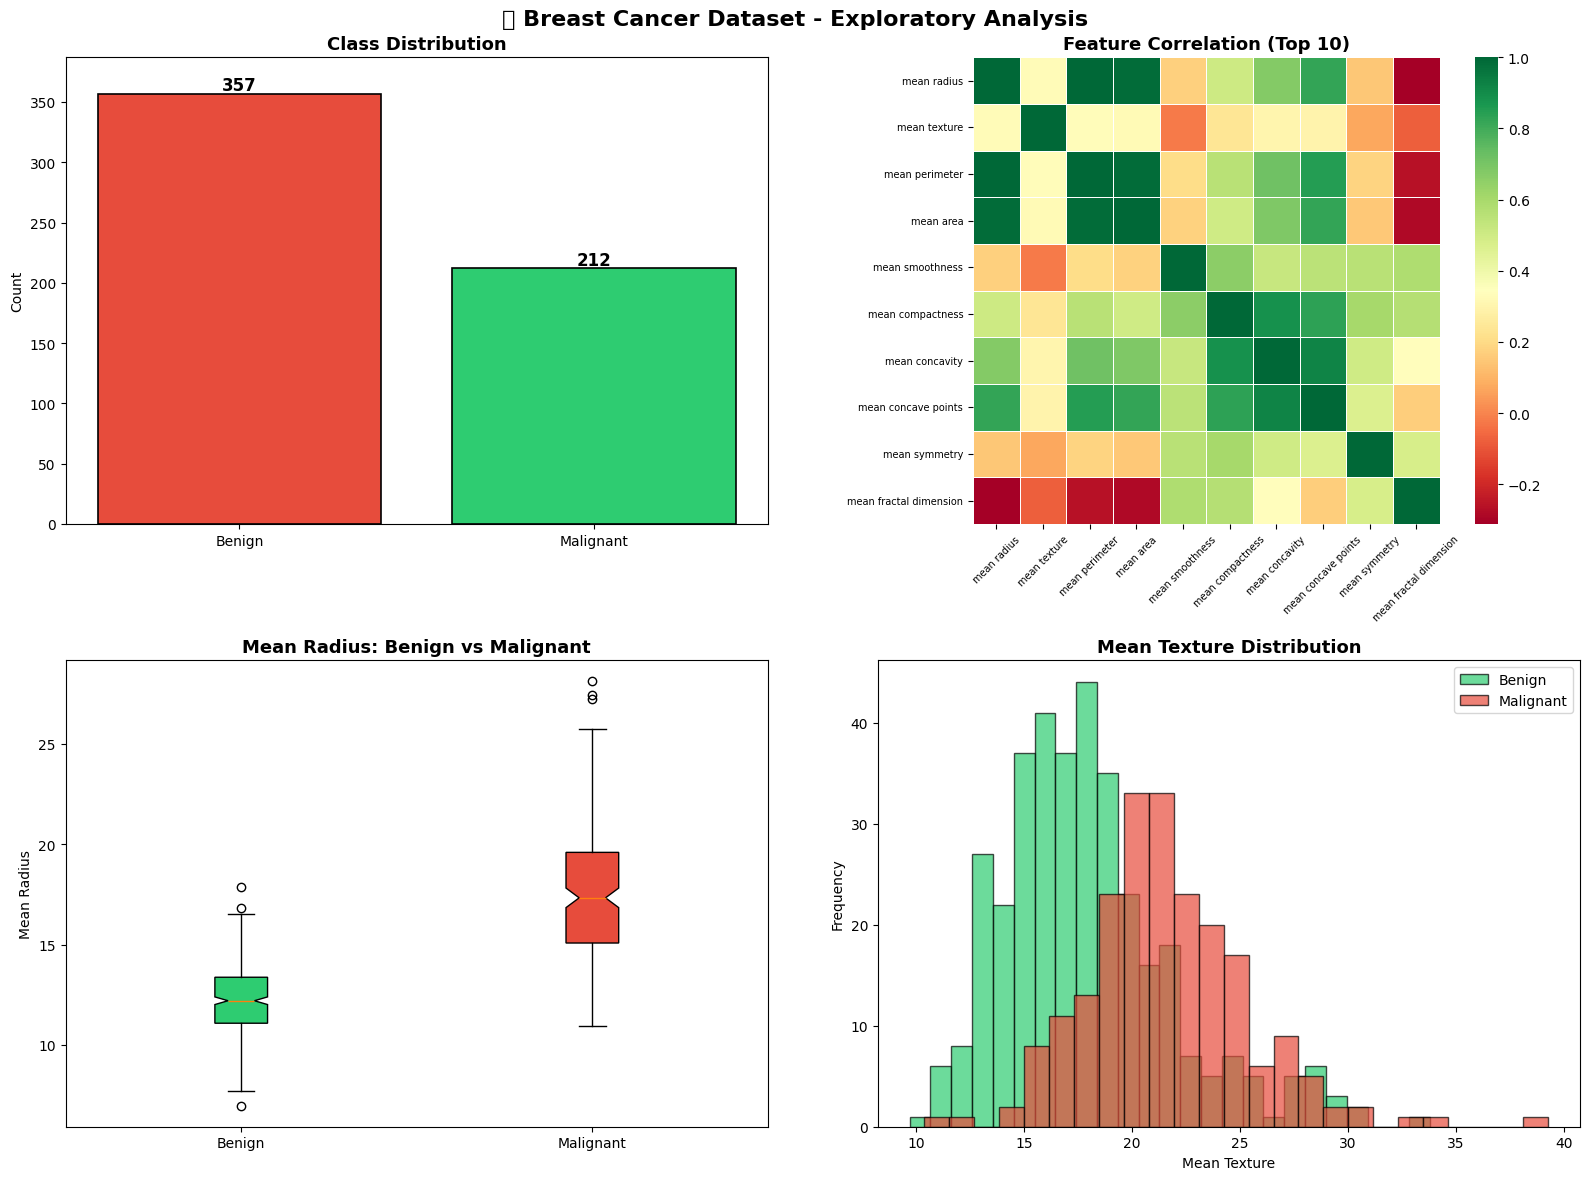

✅ EDA Visualization complete!
🔪 Train size : 455 samples
🔪 Test size  : 114 samples
✅ Data preprocessed!

       🚀 ADABOOST CLASSIFIER

✅ Test Accuracy   : 95.61%
✅ ROC-AUC Score   : 0.9835
✅ CV Accuracy (5) : 97.01%

📋 Classification Report:
              precision    recall  f1-score   support

   Malignant       0.97      0.90      0.94        42
      Benign       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



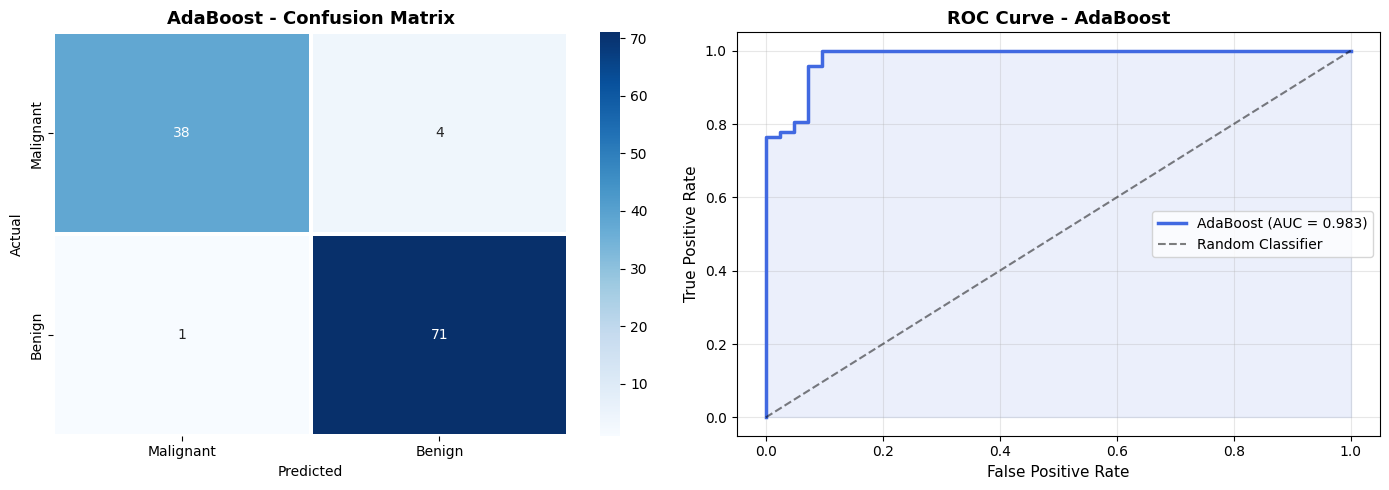

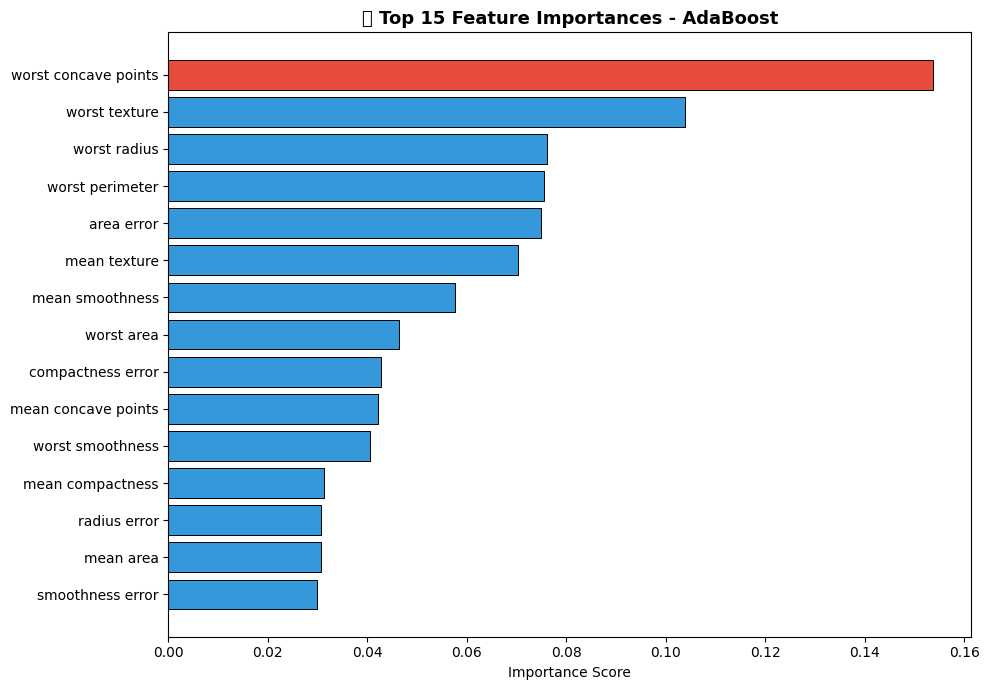


🥇 Most Important Feature: worst concave points

   📊 COMPARISON: Multiple Classifiers
🚀 AdaBoost                Acc=95.61%  AUC=0.9818  CV=97.72%
🌲 Random Forest           Acc=95.61%  AUC=0.9939  CV=95.61%
⚡ Gradient Boosting       Acc=95.61%  AUC=0.9907  CV=96.31%
🌿 Decision Tree           Acc=91.23%  AUC=0.9157  CV=91.73%
📈 Logistic Reg.           Acc=98.25%  AUC=0.9954  CV=98.07%
🔷 SVM                     Acc=98.25%  AUC=0.9950  CV=97.36%


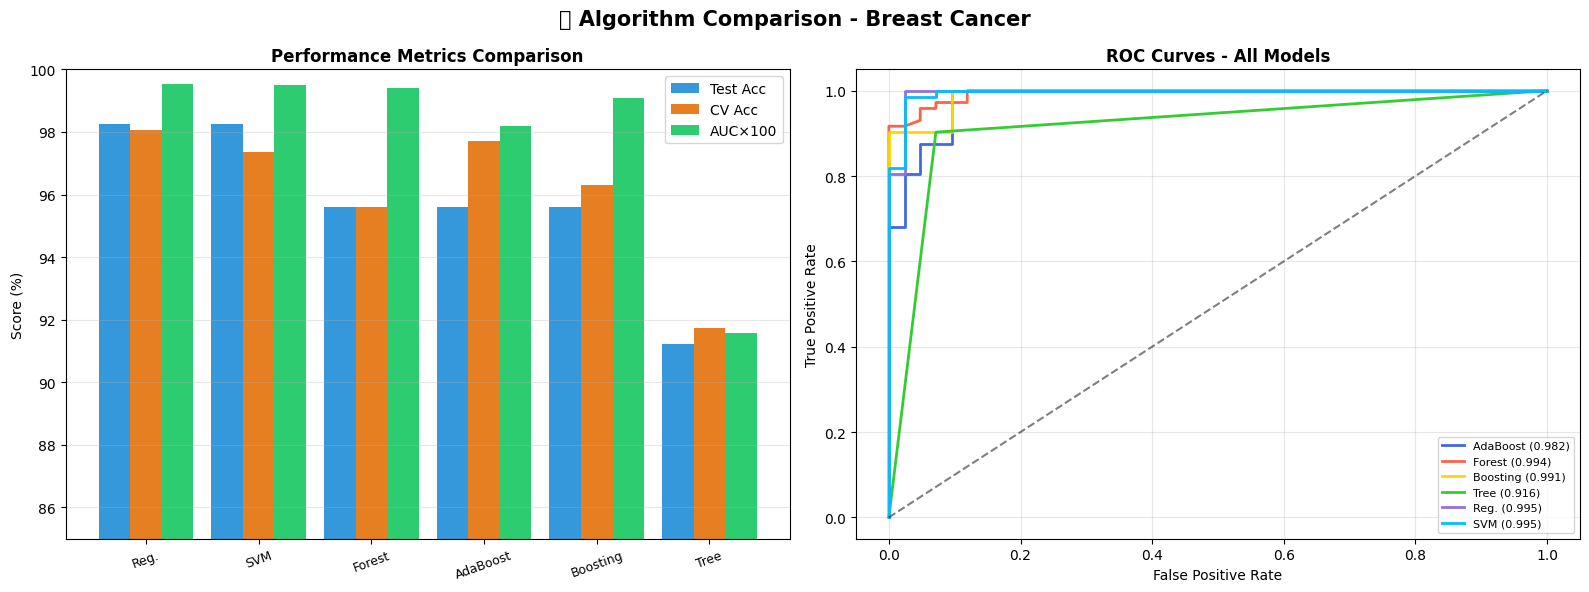


   🔮 PREDICT FROM USER INPUT

--- Sample 1 (Benign) ---

🔍 Prediction  : ⚠️ MALIGNANT (Cancerous)
   Probability : Benign=19.4%  |  Malignant=80.6%
   Confidence  : MEDIUM (80.6%)

--- Sample 2 (Malignant) ---

🔍 Prediction  : ⚠️ MALIGNANT (Cancerous)
   Probability : Benign=19.4%  |  Malignant=80.6%
   Confidence  : MEDIUM (80.6%)

--- 🖊️ Custom Input ---

🔍 Prediction  : ✅ BENIGN (Non-cancerous)
   Probability : Benign=65.3%  |  Malignant=34.7%
   Confidence  : MEDIUM (65.3%)

   📊 FINAL RESULTS SUMMARY
              Model  Test Acc (%)  ROC-AUC  CV Acc (%)
    📈 Logistic Reg.         98.25   0.9954       98.07
              🔷 SVM         98.25   0.9950       97.36
    🌲 Random Forest         95.61   0.9939       95.61
         🚀 AdaBoost         95.61   0.9818       97.72
⚡ Gradient Boosting         95.61   0.9907       96.31
    🌿 Decision Tree         91.23   0.9157       91.73

🏆 Best Model   : 📈 Logistic Reg.
   Test Acc    : 98.25%
   ROC-AUC     : 0.9954

🎯 AdaBoost     : Acc

In [1]:
# ============================================================
#   🎯 ADABOOST BREAST CANCER CLASSIFICATION PROJECT
#   ✅ Data Visualization | Model Evaluation | Predictions
#   ✅ Comparison with Other Algorithms
#   📌 Run this in Google Colab cell by cell
# ============================================================

# ── CELL 1: Install & Imports ──────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)

# Models
from sklearn.ensemble import (AdaBoostClassifier, RandomForestClassifier,
                               GradientBoostingClassifier)
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

print("✅ All libraries imported successfully!")


# ── CELL 2: Load & Explore Dataset ────────────────────────
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df['diagnosis'] = df['target'].map({1: 'Benign', 0: 'Malignant'})

print("📊 Dataset Shape:", df.shape)
print("\n🔢 Class Distribution:")
print(df['diagnosis'].value_counts())
print("\n📋 First 5 Rows:")
df.head()


# ── CELL 3: Data Visualization ────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('🔬 Breast Cancer Dataset - Exploratory Analysis', fontsize=16, fontweight='bold')

# 1. Class Distribution
ax1 = axes[0, 0]
colors = ['#e74c3c', '#2ecc71']
counts = df['diagnosis'].value_counts()
bars = ax1.bar(counts.index, counts.values, color=colors, edgecolor='black', linewidth=1.2)
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             str(val), ha='center', fontweight='bold', fontsize=12)
ax1.set_title('Class Distribution', fontsize=13, fontweight='bold')
ax1.set_ylabel('Count')
ax1.set_ylim(0, max(counts.values) + 30)

# 2. Feature Correlation Heatmap (top 10 features)
ax2 = axes[0, 1]
top_features = df[data.feature_names[:10]].corr()
sns.heatmap(top_features, ax=ax2, cmap='RdYlGn', annot=False,
            linewidths=0.5, square=True)
ax2.set_title('Feature Correlation (Top 10)', fontsize=13, fontweight='bold')
ax2.tick_params(axis='x', rotation=45, labelsize=7)
ax2.tick_params(axis='y', labelsize=7)

# 3. Boxplot - Mean Radius by Diagnosis
ax3 = axes[1, 0]
benign = df[df['diagnosis'] == 'Benign']['mean radius']
malignant = df[df['diagnosis'] == 'Malignant']['mean radius']
bp = ax3.boxplot([benign, malignant], labels=['Benign', 'Malignant'],
                 patch_artist=True, notch=True)
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')
ax3.set_title('Mean Radius: Benign vs Malignant', fontsize=13, fontweight='bold')
ax3.set_ylabel('Mean Radius')

# 4. Histogram - Mean Texture
ax4 = axes[1, 1]
ax4.hist(df[df['diagnosis']=='Benign']['mean texture'],
         bins=25, alpha=0.7, color='#2ecc71', label='Benign', edgecolor='black')
ax4.hist(df[df['diagnosis']=='Malignant']['mean texture'],
         bins=25, alpha=0.7, color='#e74c3c', label='Malignant', edgecolor='black')
ax4.set_title('Mean Texture Distribution', fontsize=13, fontweight='bold')
ax4.set_xlabel('Mean Texture')
ax4.set_ylabel('Frequency')
ax4.legend()

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA Visualization complete!")


# ── CELL 4: Preprocessing & Split ─────────────────────────
X = df[data.feature_names]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"🔪 Train size : {X_train.shape[0]} samples")
print(f"🔪 Test size  : {X_test.shape[0]} samples")
print("✅ Data preprocessed!")


# ── CELL 5: AdaBoost Model ────────────────────────────────
print("\n" + "="*50)
print("       🚀 ADABOOST CLASSIFIER")
print("="*50)

ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)
ada.fit(X_train_sc, y_train)
y_pred_ada  = ada.predict(X_test_sc)
y_prob_ada  = ada.predict_proba(X_test_sc)[:, 1]

ada_acc  = accuracy_score(y_test, y_pred_ada)
ada_auc  = roc_auc_score(y_test, y_prob_ada)
ada_cv   = cross_val_score(ada, scaler.transform(X), y, cv=5).mean()

print(f"\n✅ Test Accuracy   : {ada_acc*100:.2f}%")
print(f"✅ ROC-AUC Score   : {ada_auc:.4f}")
print(f"✅ CV Accuracy (5) : {ada_cv*100:.2f}%")
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred_ada, target_names=['Malignant','Benign']))


# ── CELL 6: Confusion Matrix ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_ada)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant','Benign'],
            yticklabels=['Malignant','Benign'],
            ax=axes[0], linewidths=1.5)
axes[0].set_title('AdaBoost - Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_ada)
axes[1].plot(fpr, tpr, color='royalblue', lw=2.5,
             label=f'AdaBoost (AUC = {ada_auc:.3f})')
axes[1].plot([0,1],[0,1],'k--', lw=1.5, alpha=0.5, label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='royalblue')
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title('ROC Curve - AdaBoost', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('adaboost_results.png', dpi=150, bbox_inches='tight')
plt.show()


# ── CELL 7: Feature Importance ────────────────────────────
importances = pd.Series(ada.feature_importances_, index=data.feature_names)
top15 = importances.nlargest(15).sort_values()

plt.figure(figsize=(10, 7))
colors_bar = ['#e74c3c' if v == top15.max() else '#3498db' for v in top15]
bars = plt.barh(top15.index, top15.values, color=colors_bar, edgecolor='black', linewidth=0.7)
plt.title('🔑 Top 15 Feature Importances - AdaBoost', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n🥇 Most Important Feature: {importances.idxmax()}")


# ── CELL 8: Algorithm Comparison ─────────────────────────
print("\n" + "="*55)
print("   📊 COMPARISON: Multiple Classifiers")
print("="*55)

models = {
    '🚀 AdaBoost'          : AdaBoostClassifier(n_estimators=100, random_state=42),
    '🌲 Random Forest'     : RandomForestClassifier(n_estimators=100, random_state=42),
    '⚡ Gradient Boosting' : GradientBoostingClassifier(n_estimators=100, random_state=42),
    '🌿 Decision Tree'     : DecisionTreeClassifier(random_state=42),
    '📈 Logistic Reg.'     : LogisticRegression(max_iter=1000, random_state=42),
    '🔷 SVM'               : SVC(probability=True, random_state=42),
}

results = []
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    preds = model.predict(X_test_sc)
    probs = model.predict_proba(X_test_sc)[:, 1]
    acc   = accuracy_score(y_test, preds)
    auc   = roc_auc_score(y_test, probs)
    cv    = cross_val_score(model, scaler.transform(X), y, cv=5).mean()
    results.append({'Model': name, 'Test Acc (%)': round(acc*100,2),
                    'ROC-AUC': round(auc,4), 'CV Acc (%)': round(cv*100,2)})
    print(f"{name:<25} Acc={acc*100:.2f}%  AUC={auc:.4f}  CV={cv*100:.2f}%")

results_df = pd.DataFrame(results).sort_values('Test Acc (%)', ascending=False)


# ── CELL 9: Comparison Chart ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('🏆 Algorithm Comparison - Breast Cancer', fontsize=15, fontweight='bold')

x = np.arange(len(results_df))
w = 0.28
c1, c2, c3 = '#3498db', '#e67e22', '#2ecc71'

axes[0].bar(x - w, results_df['Test Acc (%)'], w, label='Test Acc', color=c1)
axes[0].bar(x,     results_df['CV Acc (%)'],   w, label='CV Acc',   color=c2)
axes[0].bar(x + w, results_df['ROC-AUC']*100,  w, label='AUC×100',  color=c3)
axes[0].set_xticks(x)
axes[0].set_xticklabels([m.split()[-1] for m in results_df['Model']], rotation=20, fontsize=9)
axes[0].set_ylabel('Score (%)')
axes[0].set_title('Performance Metrics Comparison', fontweight='bold')
axes[0].legend()
axes[0].set_ylim(85, 100)
axes[0].grid(axis='y', alpha=0.3)

# ROC curves for all models
all_colors = ['royalblue','tomato','gold','limegreen','mediumpurple','deepskyblue']
for i, (name, model) in enumerate(models.items()):
    p = model.predict_proba(X_test_sc)[:, 1]
    fpr_, tpr_, _ = roc_curve(y_test, p)
    auc_ = roc_auc_score(y_test, p)
    axes[1].plot(fpr_, tpr_, lw=2, color=all_colors[i],
                 label=f"{name.split()[-1]} ({auc_:.3f})")
axes[1].plot([0,1],[0,1],'k--', lw=1.5, alpha=0.5)
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves - All Models', fontweight='bold')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()


# ── CELL 10: User Input Prediction ───────────────────────
print("\n" + "="*55)
print("   🔮 PREDICT FROM USER INPUT")
print("="*55)

def predict_cancer(feature_values: list):
    """
    Pass a list of 30 feature values in the same order
    as load_breast_cancer().feature_names
    """
    features = np.array(feature_values).reshape(1, -1)
    features_sc = scaler.transform(features)
    pred  = ada.predict(features_sc)[0]
    proba = ada.predict_proba(features_sc)[0]
    label = "✅ BENIGN (Non-cancerous)" if pred == 1 else "⚠️ MALIGNANT (Cancerous)"

    print(f"\n🔍 Prediction  : {label}")
    print(f"   Probability : Benign={proba[1]*100:.1f}%  |  Malignant={proba[0]*100:.1f}%")
    print(f"   Confidence  : {'HIGH' if max(proba)>0.85 else 'MEDIUM'} ({max(proba)*100:.1f}%)")
    return pred, proba

# ── Example: use mean values of a Benign sample ──────────
sample_benign    = X_test.iloc[0].values.tolist()
sample_malignant = X_test[y_test == 0].iloc[0].values.tolist()

print("\n--- Sample 1 (Benign) ---")
predict_cancer(sample_benign)

print("\n--- Sample 2 (Malignant) ---")
predict_cancer(sample_malignant)

# ── Custom input (edit these values!) ────────────────────
print("\n--- 🖊️ Custom Input ---")
# Replace with any 30 real feature values
custom_input = list(X_test.iloc[5].values)   # change index to try others
predict_cancer(custom_input)


# ── CELL 11: Summary Table ────────────────────────────────
print("\n" + "="*55)
print("   📊 FINAL RESULTS SUMMARY")
print("="*55)
print(results_df.to_string(index=False))
best = results_df.iloc[0]
print(f"\n🏆 Best Model   : {best['Model']}")
print(f"   Test Acc    : {best['Test Acc (%)']}%")
print(f"   ROC-AUC     : {best['ROC-AUC']}")
print(f"\n🎯 AdaBoost     : Acc={ada_acc*100:.2f}%  AUC={ada_auc:.4f}  CV={ada_cv*100:.2f}%")
print("\n✅ PROJECT COMPLETE!")